In [1]:
!pip install -q -U torch==2.11.0 torchvision torchaudio --index-url https://download.pytorch.org/whl/cu128

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 657.9/657.9 MB 65.9 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.8/296.8 MB 105.4 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 820.3/820.3 MB 1.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 84.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 75.0 MB/s eta 0:00:00


In [2]:
!nvidia-smi -L

GPU 0: Tesla T4 (UUID: GPU-a950efad-a5b9-6645-3a9a-100e58ded983)
GPU 1: Tesla T4 (UUID: GPU-0abcc540-8c08-d781-b643-7fc4429dd86c)


In [3]:
!pip install -q -U "torchao>=0.16.0" transformers trl peft accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 94.0 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 109.5 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 992.6/992.6 kB 56.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 775.8/775.8 kB 44.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.2/389.2 kB 28.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 516.0/516.0 kB 34.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 93.6 MB/s eta 0:00:00:00:01


In [4]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "NONE")

PyTorch: 2.11.0+cu128
CUDA: True
GPU: Tesla T4


In [5]:
import gc
import torch

from datasets import load_dataset
from transformers import AutoTokenizer
from trl import KTOConfig, KTOTrainer
from peft import LoraConfig

print("PyTorch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("VRAM:",
          round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2),
          "GB")

Failed to load /usr/local/lib/python3.12/dist-packages/torchao/_C_cutlass_90a.abi3.so: Could not load this library: /usr/local/lib/python3.12/dist-packages/torchao/_C_cutlass_90a.abi3.so
Failed to load /usr/local/lib/python3.12/dist-packages/torchao/_C_mxfp8.cpython-310-x86_64-linux-gnu.so: Could not load this library: /usr/local/lib/python3.12/dist-packages/torchao/_C_mxfp8.cpython-310-x86_64-linux-gnu.so


PyTorch: 2.11.0+cu128
CUDA: True
GPU: Tesla T4
VRAM: 14.56 GB


In [6]:
DATASET_NAME = "argilla/ultrafeedback-binarized-preferences-cleaned-kto"

dataset = load_dataset(DATASET_NAME, split="train")

print(dataset)
print(dataset.column_names)

print("\nFirst example:")
print(dataset[0])

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00002.parquet:   0%|          | 0.00/87.7M [00:00<?, ?B/s]

data/train-00001-of-00002.parquet:   0%|          | 0.00/138M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/230720 [00:00<?, ? examples/s]

Dataset({
    features: ['prompt', 'completion', 'label', 'model', 'average_rating', 'annotations', 'source'],
    num_rows: 230720
})
['prompt', 'completion', 'label', 'model', 'average_rating', 'annotations', 'source']

First example:
{'prompt': 'Can you write a C++ program that prompts the user to enter the name of a country and checks if it borders the Mediterranean Sea? Here\'s some starter code to help you out:\n#include <iostream>\n#include <string>\nusing namespace std;\nint main() {\n    string country;\n    // prompt user for input\n    cout << "Enter the name of a country: ";\n    cin >> country;\n    // check if country borders the Mediterranean Sea\n    // [C++ code]\n    return 0;\n}', 'completion': 'int main() {\n    string country;\n    // prompt user for input\n    cout << "Enter the name of a country: ";\n    cin >> country;\n    // check if country borders the Mediterranean Sea\n    if (endsWith(country, "Mediterranean")) {\n        cout << "Yes, the country " << cou

In [7]:
# Keep the experiment manageable.
N_TRAIN = 4000
N_EVAL = 100

# Shuffle first so we don't accidentally select a biased slice.
dataset = dataset.shuffle(seed=42)

train_dataset = dataset.select(range(N_TRAIN))
eval_dataset = dataset.select(range(N_TRAIN, N_TRAIN + N_EVAL))

print("Train:", len(train_dataset))
print("Eval :", len(eval_dataset))

print("\nTrain label distribution:")
print(train_dataset["label"].count(True), "desirable")
print(train_dataset["label"].count(False), "undesirable")

Train: 4000
Eval : 100

Train label distribution:
3360 desirable
640 undesirable


In [8]:
for i in range(3):
    sample = train_dataset[i]

    print("=" * 80)
    print("PROMPT:")
    print(sample["prompt"][:500])

    print("\nCOMPLETION:")
    print(sample["completion"][:800])

    print("\nLABEL:", sample["label"])

PROMPT:
Given the task definition and input, reply with output. In this task, you are given a short story consisting of exactly 5 sentences where the second sentence is missing. You are given a candidate for the second sentence and you need to identify if the given sentence connects the first sentence with the rest of the story. Indicate your answer by "Yes" if it connects, otherwise "No". Do not generate anything else apart from "Yes" or "No". The given sentence is incorrect if it changes the subsequen

COMPLETION:
Ye

LABEL: True
PROMPT:
Here's a challenge for you: Can you create a program that not only extracts and visualizes data from a government aid database using Python, but also uses that data to predict future trends in the number of people relying on government aid during a pandemic? Your program should require users to input specific parameters, such as demographic information and location, and then use that information to make predictions. The program should also be able to

In [9]:
MODEL_NAME = "Qwen/Qwen2.5-1.5B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print("Pad token:", tokenizer.pad_token)
print("EOS token:", tokenizer.eos_token)

config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Pad token: <|endoftext|>
EOS token: <|im_end|>


In [10]:
peft_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=[
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj",
        "gate_proj",
        "up_proj",
        "down_proj",
    ],
)

print(peft_config)

LoraConfig(task_type='CAUSAL_LM', peft_type=<PeftType.LORA: 'LORA'>, auto_mapping=None, peft_version='0.20.0', base_model_name_or_path=None, revision=None, inference_mode=False, r=16, target_modules={'gate_proj', 'q_proj', 'down_proj', 'o_proj', 'up_proj', 'k_proj', 'v_proj'}, exclude_modules=None, lora_alpha=32, lora_dropout=0.05, fan_in_fan_out=False, bias='none', use_rslora=False, modules_to_save=None, init_lora_weights=True, layers_to_transform=None, layers_pattern=None, rank_pattern={}, alpha_pattern={}, megatron_config=None, megatron_core='megatron.core', trainable_token_indices=None, loftq_config={}, eva_config=None, corda_config=None, lora_ga_config=None, use_dora=False, velora_config=None, alora_invocation_tokens=None, use_qalora=False, qalora_group_size=16, monteclora_config=None, layer_replication=None, runtime_config=LoraRuntimeConfig(ephemeral_gpu_offload=False), lora_bias=False, target_parameters=None, use_bdlora=None, arrow_config=None, ensure_weight_tying=False)


In [11]:
training_args = KTOConfig(
    output_dir="./qwen-1.5b-kto",

    # Precision
    bf16=torch.cuda.is_available() and torch.cuda.is_bf16_supported(),
    fp16=torch.cuda.is_available() and not torch.cuda.is_bf16_supported(),

    # Speed
    max_length=384,

    # Each GPU gets this batch
    per_device_train_batch_size=2,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=4,

    # Memory
    gradient_checkpointing=True,
    gradient_checkpointing_kwargs={"use_reentrant": False},

    # Experiment size
    max_steps=500,

    # Optimization
    learning_rate=5e-5,
    lr_scheduler_type="cosine",
    warmup_steps=10,
    max_grad_norm=1.0,

    # KTO
    beta=0.1,
    desirable_weight=1.0,
    undesirable_weight=1.0,

    # Logging / evaluation
    logging_strategy="steps",
    logging_steps=10,
    eval_strategy="steps",
    eval_steps=50,

    # Saving
    save_strategy="steps",
    save_steps=100,
    save_total_limit=2,

    seed=42,
    report_to="none",
    precompute_ref_log_probs=False,
)

In [12]:
example = train_dataset[0]

prompt = example["prompt"]
completion = example["completion"]

prompt_ids = tokenizer(prompt)["input_ids"]
combined_ids = tokenizer(prompt + completion)["input_ids"]

print("prompt length:", len(prompt_ids))
print("combined length:", len(combined_ids))
print(
    "Prefix matches:",
    combined_ids[:len(prompt_ids)] == prompt_ids
)

if combined_ids[:len(prompt_ids)] != prompt_ids:
    for i, (a, b) in enumerate(zip(prompt_ids, combined_ids)):
        if a != b:
            print("FIRST MISMATCH")
            print("position:", i)
            print("prompt:", a, repr(tokenizer.decode([a])))
            print("combined:", b, repr(tokenizer.decode([b])))
            break

prompt length: 199
combined length: 200
Prefix matches: True


In [13]:
from accelerate import notebook_launcher

def train_kto():

    trainer = KTOTrainer(
        model=MODEL_NAME,
        ref_model=None,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=eval_dataset,
        processing_class=tokenizer,
        peft_config=peft_config,
    )

    trainer.model.print_trainable_parameters()

    trainer.train()

    trainer.save_model("./qwen-1.5b-kto-final")

In [14]:
import torch
from transformers import AutoModelForCausalLM
from peft import LoraConfig, get_peft_model

model = AutoModelForCausalLM.from_pretrained(
    "Qwen/Qwen2.5-1.5B-Instruct",
    torch_dtype=torch.bfloat16 if torch.cuda.is_available()
               and torch.cuda.is_bf16_supported()
               else torch.float16,
)

lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=[
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj",
        "gate_proj",
        "up_proj",
        "down_proj",
    ],
)

try:
    model = get_peft_model(model, lora_config)
    model.print_trainable_parameters()
    print("✅ LoRA wrapping works")
except Exception as e:
    import traceback
    traceback.print_exc()

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

trainable params: 18,464,768 || all params: 1,562,179,072 || trainable%: 1.1820
✅ LoRA wrapping works


In [15]:
# notebook_launcher(
#     train_kto,
#     num_processes=2
# )

In [16]:
import matplotlib.pyplot as plt
import pandas as pd

trainer = KTOTrainer(
    model=MODEL_NAME,
    ref_model=None,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    processing_class=tokenizer,
    peft_config=peft_config,
)

trainer.model.print_trainable_parameters()

# Train
train_result = trainer.train()

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Adding EOS to train dataset:   0%|          | 0/4000 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/4000 [00:00<?, ? examples/s]

[RANK 0] Mismatch between tokenized prompt and the start of tokenized prompt+completion. This may be due to unexpected tokenizer behavior, whitespace issues, or special token handling. Verify that the tokenizer is processing text consistently.
[RANK 0] Mismatch between tokenized prompt and the start of tokenized prompt+completion. This may be due to unexpected tokenizer behavior, whitespace issues, or special token handling. Verify that the tokenizer is processing text consistently.
[RANK 0] Mismatch between tokenized prompt and the start of tokenized prompt+completion. This may be due to unexpected tokenizer behavior, whitespace issues, or special token handling. Verify that the tokenizer is processing text consistently.
[RANK 0] Mismatch between tokenized prompt and the start of tokenized prompt+completion. This may be due to unexpected tokenizer behavior, whitespace issues, or special token handling. Verify that the tokenizer is processing text consistently.
[RANK 0] Mismatch betwee

Dropping fully truncated examples from train dataset:   0%|          | 0/4000 [00:00<?, ? examples/s]

...

Dropping fully truncated examples from eval dataset:   0%|          | 0/100 [00:00<?, ? examples/s]

Extracting KL eval dataset:   0%|          | 0/90 [00:00<?, ? examples/s]

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


trainable params: 18,464,768 || all params: 1,562,179,072 || trainable%: 1.1820


Step,Training Loss,Validation Loss,Kl,Entropy,Num Tokens,Logits/chosen,Rewards/chosen,Logps/chosen,Logits/rejected,Rewards/rejected,Logps/rejected,Rewards/margins
50,0.541089,0.517236,17.228090,1.113580,111649.000000,-0.536472,1.680796,-223.732662,-0.373705,1.848901,-126.117683,-0.138609
100,0.476559,0.511759,25.193639,1.089940,221672.000000,-0.484084,2.529386,-215.246758,-0.366402,2.723669,-117.369997,-0.196441
150,0.502001,0.508296,27.204477,1.082168,327538.000000,-0.514562,2.752246,-213.018158,-0.368338,2.950171,-115.104981,-0.190438
200,0.508504,0.493715,27.625921,1.069978,437651.000000,-0.570776,2.871546,-211.825161,-0.374061,2.954298,-115.063706,-0.056442
250,0.483575,0.484328,27.766106,1.043289,544640.000000,-0.656290,2.961367,-210.926950,-0.437000,2.960050,-115.006190,0.051371
300,0.518142,0.469057,27.317632,1.066480,651988.000000,-0.579005,3.015244,-210.388178,-0.411084,3.006033,-114.546358,0.059857
350,0.440321,0.463162,27.233760,1.065809,756953.000000,-0.577454,3.036258,-210.178032,-0.406508,3.007518,-114.531509,0.084367
400,0.468421,0.458627,27.152170,1.058153,865160.000000,-0.608228,3.063670,-209.903916,-0.443373,3.015284,-114.453844,0.092845
450,0.401681,0.456310,27.072382,1.055951,973663.000000,-0.616883,3.076522,-209.775399,-0.456644,3.008034,-114.526348,0.100617
500,0.379655,0.456935,27.055909,1.053853,1084215.000000,-0.625696,3.070625,-209.834364,-0.463801,3.012432,-114.482366,0.091602


Available metrics:
['loss', 'grad_norm', 'learning_rate', 'kl', 'entropy', 'num_tokens', 'logits/chosen', 'rewards/chosen', 'logps/chosen', 'logits/rejected', 'rewards/rejected', 'logps/rejected', 'rewards/margins', 'epoch', 'step', 'eval_loss', 'eval_runtime', 'eval_samples_per_second', 'eval_steps_per_second', 'eval_kl', 'eval_entropy', 'eval_num_tokens', 'eval_logits/chosen', 'eval_rewards/chosen', 'eval_logps/chosen', 'eval_logits/rejected', 'eval_rewards/rejected', 'eval_logps/rejected', 'eval_rewards/margins', 'train_runtime', 'train_samples_per_second', 'train_steps_per_second', 'total_flos', 'train_loss']

Last metrics:


,loss,grad_norm,learning_rate,kl,entropy,num_tokens,logits/chosen,rewards/chosen,logps/chosen,logits/rejected,...,eval_logps/chosen,eval_logits/rejected,eval_rewards/rejected,eval_logps/rejected,eval_rewards/margins,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
51,0.472039,1.973850,1.887707e-06,28.932531,1.121731,953200.0,-0.202943,3.062128,-224.789760,0.341868,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
52,0.401681,2.082407,1.324601e-06,28.717072,1.123852,973663.0,-0.544479,3.435736,-213.601409,0.011331,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
53,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-209.775399,-0.456644,3.008034,-114.526348,0.100617,NaN,NaN,NaN,NaN,NaN
54,0.354120,2.650193,8.587823e-07,32.210641,1.092899,995807.0,-0.276842,4.060037,-228.737430,-0.179763,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
55,0.454339,1.828206,4.921651e-07,34.415326,1.082117,1017014.0,-0.293284,3.920765,-183.433177,0.060357,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
56,0.355213,2.390036,2.262560e-07,28.720446,1.160596,1038144.0,-0.355149,3.820928,-204.859736,0.337331,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
57,0.438357,2.544668,6.214740e-08,31.349788,1.249414,1061928.0,-0.376333,3.533650,-232.180675,-0.169892,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
58,0.379655,2.050593,5.138260e-10,31.134899,1.090409,1084215.0,-0.513031,4.121035,-218.221430,0.144784,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
59,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-209.834364,-0.463801,3.012432,-114.482366,0.091602,NaN,NaN,NaN,NaN,NaN
60,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,14887.9687,0.269,0.034,1.071203e+16,0.484773


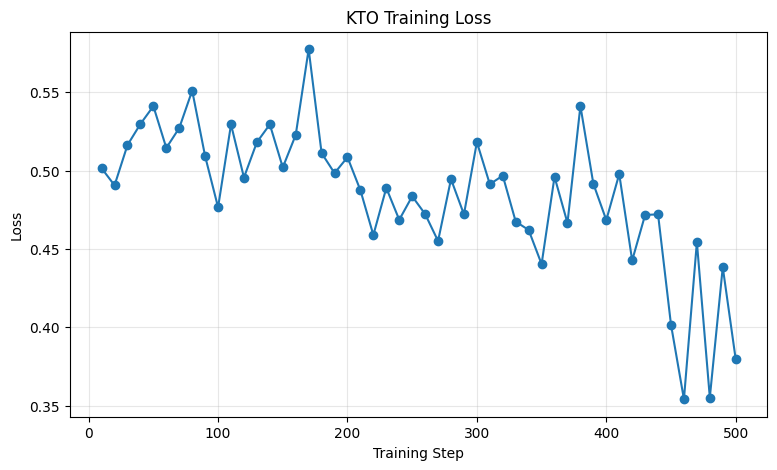

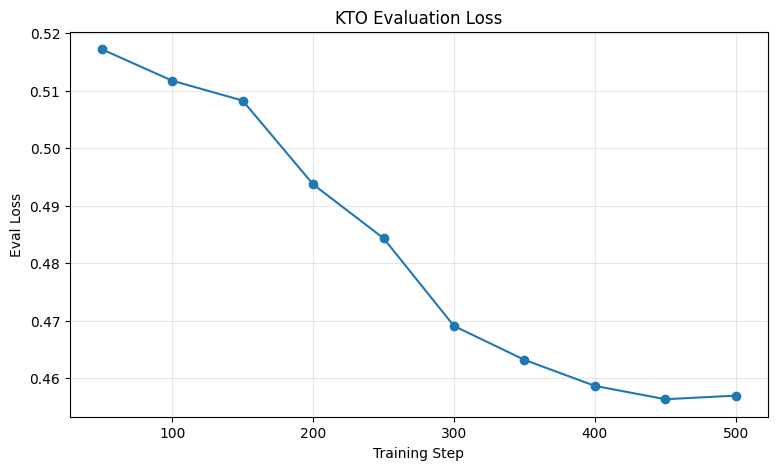

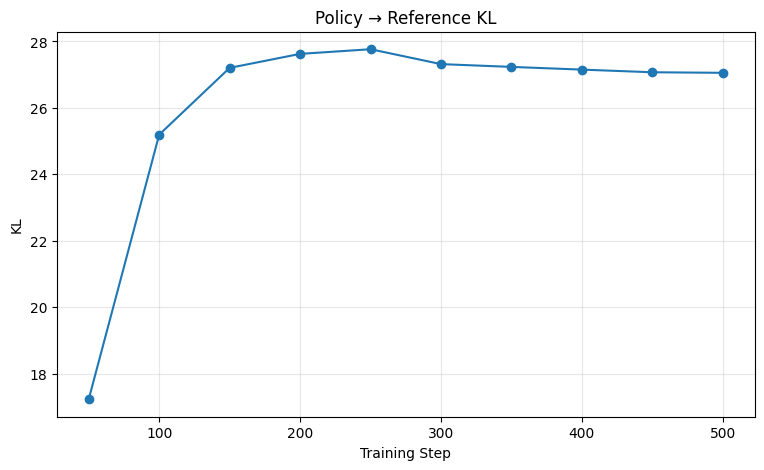

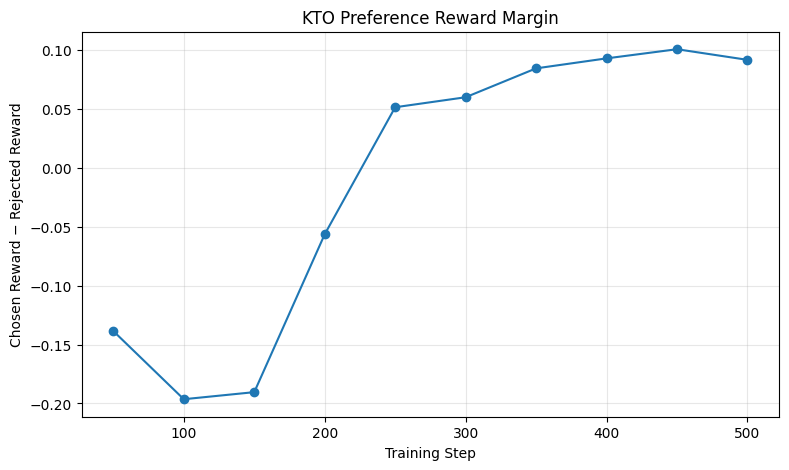

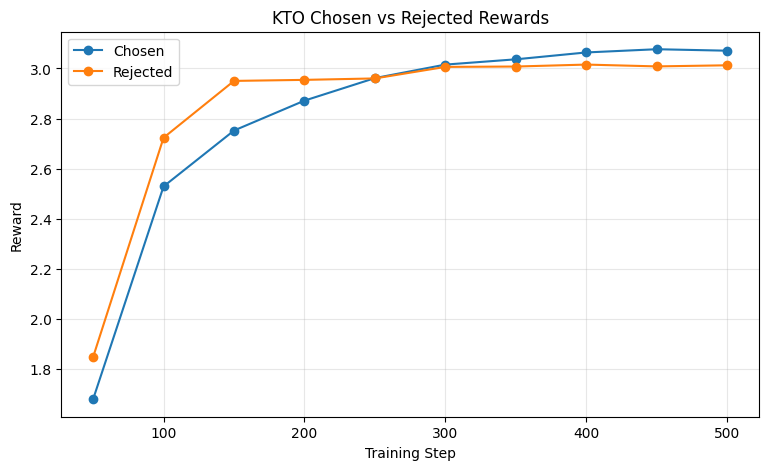

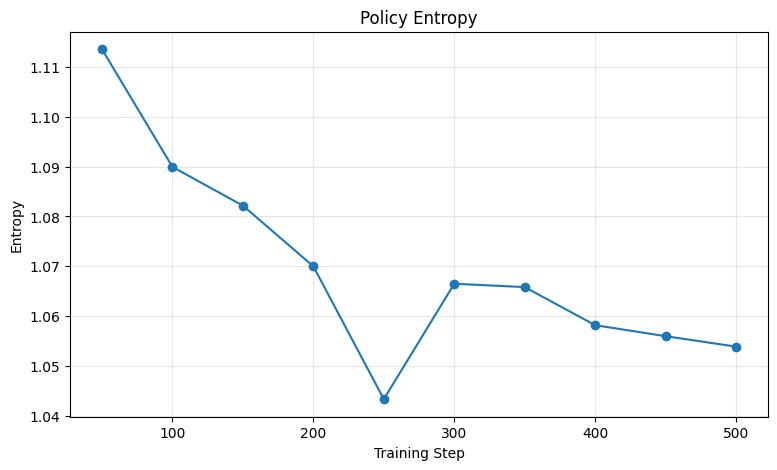

In [17]:

history = pd.DataFrame(trainer.state.log_history)

print("Available metrics:")
print(history.columns.tolist())

# Save raw history
history.to_csv("./kto_training_history.csv", index=False)

print("\nLast metrics:")
display(history.tail(10))


# ---------------------------------------------------------
# Helper: plot a metric if it exists
# ---------------------------------------------------------

def plot_metric(df, column, title, ylabel=None):
    if column not in df.columns:
        print(f"Skipping {column}: not found")
        return

    data = df[["step", column]].dropna()

    if len(data) == 0:
        print(f"Skipping {column}: no values")
        return

    plt.figure(figsize=(9, 5))
    plt.plot(data["step"], data[column], marker="o")
    plt.xlabel("Training Step")
    plt.ylabel(ylabel or column)
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.show()


# ---------------------------------------------------------
# Training loss
# ---------------------------------------------------------

plot_metric(
    history,
    "loss",
    "KTO Training Loss",
    "Loss"
)


# ---------------------------------------------------------
# Evaluation loss
# ---------------------------------------------------------

plot_metric(
    history,
    "eval_loss",
    "KTO Evaluation Loss",
    "Eval Loss"
)


# ---------------------------------------------------------
# KL divergence
# ---------------------------------------------------------

plot_metric(
    history,
    "eval_kl",
    "Policy → Reference KL",
    "KL"
)


# ---------------------------------------------------------
# Reward margin — MOST IMPORTANT
# ---------------------------------------------------------

plot_metric(
    history,
    "eval_rewards/margins",
    "KTO Preference Reward Margin",
    "Chosen Reward − Rejected Reward"
)


# ---------------------------------------------------------
# Chosen vs rejected rewards
# ---------------------------------------------------------

if (
    "eval_rewards/chosen" in history.columns
    and "eval_rewards/rejected" in history.columns
):
    data = history[
        ["step", "eval_rewards/chosen", "eval_rewards/rejected"]
    ].dropna()

    plt.figure(figsize=(9, 5))

    plt.plot(
        data["step"],
        data["eval_rewards/chosen"],
        marker="o",
        label="Chosen"
    )

    plt.plot(
        data["step"],
        data["eval_rewards/rejected"],
        marker="o",
        label="Rejected"
    )

    plt.xlabel("Training Step")
    plt.ylabel("Reward")
    plt.title("KTO Chosen vs Rejected Rewards")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


# ---------------------------------------------------------
# Entropy
# ---------------------------------------------------------

plot_metric(
    history,
    "eval_entropy",
    "Policy Entropy",
    "Entropy"
)


# ---------------------------------------------------------
# Save final model
# ---------------------------------------------------------


In [18]:
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

after = trainer.evaluate()

print("\nAFTER KTO")
for k, v in after.items():
    if isinstance(v, (int, float)):
        print(f"{k}: {v}")

Training Loss,Validation Loss,Step,Kl,Entropy,Num Tokens,Logits/chosen,Rewards/chosen,Logps/chosen,Logits/rejected,Rewards/rejected,Logps/rejected,Rewards/margins
0.379655,0.456935,500,27.055909,1.053853,1084215.000000,-0.625696,3.070625,-209.834364,-0.463801,3.012432,-114.482366,0.091602



AFTER KTO
eval_loss: 0.45693469047546387
eval_kl: 27.055908534837805
eval_entropy: 1.0538534988527712
eval_num_tokens: 1084215.0
eval_logits/chosen: -0.6256959373614398
eval_rewards/chosen: 3.0706253950146665
eval_logps/chosen: -209.83436352273694
eval_logits/rejected: -0.4638008744232548
eval_rewards/rejected: 3.012432364953889
eval_logps/rejected: -114.48236634996202
eval_rewards/margins: 0.09160170566152646


In [19]:
SAVE_PATH = "./qwen-1.5b-kto-final"

trainer.save_model(SAVE_PATH)
tokenizer.save_pretrained(SAVE_PATH)

print("Saved to:", SAVE_PATH)

Saved to: ./qwen-1.5b-kto-final


In [20]:
import torch

device = trainer.model.device

def generate_response(prompt):
    messages = [
        {"role": "user", "content": prompt}
    ]

    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )

    inputs = tokenizer(
        text,
        return_tensors="pt"
    ).to(device)

    with torch.no_grad():
        outputs = trainer.model.generate(
            **inputs,
            max_new_tokens=150,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id,
        )

    generated = outputs[0][inputs["input_ids"].shape[1]:]

    return tokenizer.decode(
        generated,
        skip_special_tokens=True
    )


prompts = [
    "Explain why the sky appears blue.",
    "Write a Python function that checks whether a number is prime.",
    "What is the difference between supervised and reinforcement learning?"
]

for prompt in prompts:
    print("=" * 80)
    print("PROMPT:", prompt)
    print("\nRESPONSE:")
    print(generate_response(prompt))

PROMPT: Explain why the sky appears blue.

RESPONSE:
The sky appears blue because of a phenomenon called Rayleigh scattering. This occurs when sunlight passes through Earth's atmosphere and interacts with molecules in the air, such as nitrogen and oxygen.

As light travels from the sun to our eyes, it encounters these molecules. The shorter wavelengths (blue and violet) of light are scattered more easily than longer wavelengths (red and orange). This is because they have less energy and can be deflected more easily by the molecules in the air.

When we look at the sky during the day, we see this scattered light coming back towards us. The blue color that we perceive comes from the scattered blue light waves.
PROMPT: Write a Python function that checks whether a number is prime.

RESPONSE:
Sure! Here's an example of a Python function that checks whether a given number is prime:

```python
def is_prime(n):
    if n <= 1:
        return False
    for i in range(2, int(n**0.5) + 1):
      